In [1]:
from ultralytics.data.converter import convert_coco
from pathlib import Path
import yaml
import shutil

# -------------------------------------------------------------------
# 1. CONFIGURATION — point this to your extracted Roboflow download
# -------------------------------------------------------------------
ROBOFLOW_EXPORT_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Breed Segmentation.v1i.coco-segmentation (1)")
# expected inside: train/, valid/, test/ — each with images + _annotations.coco.json

YOLO_DATASET_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset")
YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import json

# -------------------------------------------------------------------
# 1. LOAD one split's COCO JSON and inspect it for problem annotations
# -------------------------------------------------------------------
coco_json_path = ROBOFLOW_EXPORT_DIR / "train" / "_annotations.coco.json"

with open(coco_json_path, "r") as f:
    coco_data = json.load(f)

print("Total images:", len(coco_data["images"]))
print("Total annotations:", len(coco_data["annotations"]))
print("Total categories:", len(coco_data["categories"]))

valid_category_ids = {cat["id"] for cat in coco_data["categories"]}

# -------------------------------------------------------------------
# 2. CHECK every annotation for missing/invalid fields
# -------------------------------------------------------------------
problems = {
    "missing_bbox": [],
    "bbox_has_none": [],
    "missing_segmentation": [],
    "empty_segmentation": [],
    "bad_category_id": [],
}

for ann in coco_data["annotations"]:
    ann_id = ann.get("id")

    bbox = ann.get("bbox")
    if bbox is None:
        problems["missing_bbox"].append(ann_id)
    elif any(v is None for v in bbox):
        problems["bbox_has_none"].append(ann_id)

    seg = ann.get("segmentation")
    if seg is None:
        problems["missing_segmentation"].append(ann_id)
    elif isinstance(seg, list) and len(seg) == 0:
        problems["empty_segmentation"].append(ann_id)

    if ann.get("category_id") not in valid_category_ids:
        problems["bad_category_id"].append(ann_id)

for problem_type, ann_ids in problems.items():
    print(f"{problem_type}: {len(ann_ids)} annotation(s)", ann_ids[:5] if ann_ids else "")

Total images: 3087
Total annotations: 6518
Total categories: 29
missing_bbox: 0 annotation(s) 
bbox_has_none: 0 annotation(s) 
missing_segmentation: 0 annotation(s) 
empty_segmentation: 0 annotation(s) 
bad_category_id: 0 annotation(s) 


In [3]:
# -------------------------------------------------------------------
# DEEPER CHECK: inspect segmentation content itself, not just presence
# -------------------------------------------------------------------
rle_segmentations = []
none_in_polygon = []
odd_length_polygon = []
iscrowd_flagged = []
non_list_non_dict = []

for ann in coco_data["annotations"]:
    ann_id = ann.get("id")
    seg = ann.get("segmentation")

    if ann.get("iscrowd", 0) == 1:
        iscrowd_flagged.append(ann_id)

    if isinstance(seg, dict):
        rle_segmentations.append(ann_id)
    elif isinstance(seg, list):
        for poly in seg:
            if not isinstance(poly, list):
                non_list_non_dict.append(ann_id)
                continue
            if any(v is None for v in poly):
                none_in_polygon.append(ann_id)
            if len(poly) % 2 != 0:
                odd_length_polygon.append(ann_id)
    else:
        non_list_non_dict.append(ann_id)

print("RLE (dict) segmentations:", len(rle_segmentations), rle_segmentations[:5])
print("iscrowd=1 annotations:", len(iscrowd_flagged), iscrowd_flagged[:5])
print("None values inside polygon coords:", len(none_in_polygon), none_in_polygon[:5])
print("Odd-length polygons (invalid x,y pairs):", len(odd_length_polygon), odd_length_polygon[:5])
print("Segmentation neither list nor dict:", len(non_list_non_dict), non_list_non_dict[:5])

RLE (dict) segmentations: 0 []
iscrowd=1 annotations: 0 []
None values inside polygon coords: 0 []
Odd-length polygons (invalid x,y pairs): 0 []
Segmentation neither list nor dict: 0 []


In [4]:
for split in ["train", "valid", "test"]:
    split_dir = ROBOFLOW_EXPORT_DIR / split
    coco_json = split_dir / "_annotations.coco.json"

    if not coco_json.exists():
        print(f"WARNING: {coco_json} not found")
        continue

    convert_coco(
        labels_dir=str(split_dir),
        save_dir=str(YOLO_DATASET_DIR / f"{split}_converted"),
        use_segments=True,
        use_keypoints=False,
        cls91to80=False,   # <-- THE FIX: keep our own 29 custom class IDs as-is, don't remap to COCO-80
    )

    print(f"Converted {split} split.")

Annotations D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Breed Segmentation.v1i.coco-segmentation (1)\train\_annotations.coco.json: 100% ━━━━━━━━━━━━ 3087/3087 935.8it/s 3.3s0.0s
COCO data converted successfully.
Results saved to D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\train_converted
Converted train split.
Annotations D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Breed Segmentation.v1i.coco-segmentation (1)\valid\_annotations.coco.json: 100% ━━━━━━━━━━━━ 294/294 1.1Kit/s 0.3s<0.1s
COCO data converted successfully.
Results saved to D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\valid_converted-3
Converted valid split.
Annotations D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Breed Segmentation.v1i.coco-segmentation (1)\test\_annotations.coco.json: 100% ━━━━━━━━━━━━ 147/147 647.3it/s 0.2s0.1s
COCO data converted successfully.
Results saved to D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\test_converted-3
Converted test split.


In [5]:
import os

converted_folders = {
    "train": YOLO_DATASET_DIR / "train_converted-2",
    "valid": YOLO_DATASET_DIR / "valid_converted",
    "test": YOLO_DATASET_DIR / "test_converted",
}

for split, p in converted_folders.items():
    if p.exists():
        print(f"\n{split} ({p.name}):")
        for root, dirs, files in os.walk(p):
            print(" ", root, "->", files[:3], f"({len(files)} files)")
    else:
        print(f"\n{split}: FOLDER NOT FOUND at {p}")


train (train_converted-2):
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\train_converted-2 -> [] (0 files)
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\train_converted-2\images -> [] (0 files)
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\train_converted-2\labels -> [] (0 files)
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\train_converted-2\labels\_annotations.coco -> ['buffalo_alambadi__alambadi_0031_jpg.rf.48478c83fa81a65668ae517145bddb87.txt', 'buffalo_alambadi__alambadi_0031_jpg.rf.6163e27d2c09caa631aa97f6e35fef7f.txt', 'buffalo_alambadi__alambadi_0031_jpg.rf.8b6346eb67d23d216e6dc8c7bfa224af.txt'] (3087 files)

valid (valid_converted):
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\valid_converted -> [] (0 files)
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\valid_converted\images -> [] (0 files)
  D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\valid_c

In [6]:
import shutil

broken_folder = YOLO_DATASET_DIR / "train_converted"
if broken_folder.exists():
    shutil.rmtree(broken_folder)
    print("Removed broken/incomplete train_converted folder.")

Removed broken/incomplete train_converted folder.


In [7]:
import shutil
import json

# -------------------------------------------------------------------
# 1. FINAL destination structure
# -------------------------------------------------------------------
FINAL_DIR = YOLO_DATASET_DIR / "final"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

split_map = {
    "train": ("train_converted-2", "train"),
    "valid": ("valid_converted", "val"),      # renaming 'valid' -> 'val' (Ultralytics convention)
    "test":  ("test_converted", "test"),
}

# -------------------------------------------------------------------
# 2. COPY images + matching labels into final/{split}/images and final/{split}/labels
# -------------------------------------------------------------------
for src_split, (converted_folder_name, final_split_name) in split_map.items():
    src_images_dir = ROBOFLOW_EXPORT_DIR / src_split
    src_labels_dir = YOLO_DATASET_DIR / converted_folder_name / "labels" / "_annotations.coco"

    dest_images_dir = FINAL_DIR / final_split_name / "images"
    dest_labels_dir = FINAL_DIR / final_split_name / "labels"
    dest_images_dir.mkdir(parents=True, exist_ok=True)
    dest_labels_dir.mkdir(parents=True, exist_ok=True)

    copied = 0
    missing_image = []

    for label_path in src_labels_dir.glob("*.txt"):
        stem = label_path.stem  # e.g. "buffalo_alambadi__alambadi_0031_jpg.rf.48478c83..."

        # Roboflow filenames embed the original extension before '.rf.' — try common extensions
        found_image = None
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            candidate = src_images_dir / f"{stem}{ext}"
            if candidate.exists():
                found_image = candidate
                break

        if found_image is None:
            missing_image.append(stem)
            continue

        shutil.copy2(found_image, dest_images_dir / found_image.name)
        shutil.copy2(label_path, dest_labels_dir / label_path.name)
        copied += 1

    print(f"{final_split_name}: copied {copied} image+label pairs, {len(missing_image)} missing images")
    if missing_image[:3]:
        print("  Example missing:", missing_image[:3])

# -------------------------------------------------------------------
# 3. BUILD data.yaml using category order from the COCO JSON (train split's categories)
# -------------------------------------------------------------------
categories_sorted = sorted(coco_data["categories"], key=lambda c: c["id"])
class_names_ordered = [c["name"] for c in categories_sorted]

print(f"\nTotal classes: {len(class_names_ordered)}")
print("First 5:", class_names_ordered[:5])

data_yaml_content = {
    "path": str(FINAL_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {i: name for i, name in enumerate(class_names_ordered)},
}

data_yaml_path = FINAL_DIR / "data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, allow_unicode=True)

print(f"\ndata.yaml saved at: {data_yaml_path}")

train: copied 3087 image+label pairs, 0 missing images
val: copied 294 image+label pairs, 0 missing images
test: copied 147 image+label pairs, 0 missing images

Total classes: 29
First 5: ['Breed-Segmentation', 'buffalo_alambadi', 'buffalo_banni', 'buffalo_bhadawari', 'buffalo_jaffarabadi']

data.yaml saved at: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\final\data.yaml


In [8]:
# -------------------------------------------------------------------
# 1. INSPECT the raw category list and confirm the placeholder
# -------------------------------------------------------------------
categories_sorted = sorted(coco_data["categories"], key=lambda c: c["id"])
for c in categories_sorted:
    print(c["id"], "->", c["name"], "| supercategory:", c.get("supercategory"))

# -------------------------------------------------------------------
# 2. CONFIRM the placeholder category has zero real annotations
# -------------------------------------------------------------------
placeholder_id = categories_sorted[0]["id"]  # should be 0
count_using_placeholder = sum(1 for ann in coco_data["annotations"] if ann["category_id"] == placeholder_id)
print(f"\nAnnotations using placeholder category (id={placeholder_id}): {count_using_placeholder}")

0 -> Breed-Segmentation | supercategory: none
1 -> buffalo_alambadi | supercategory: Breed-Segmentation
2 -> buffalo_banni | supercategory: Breed-Segmentation
3 -> buffalo_bhadawari | supercategory: Breed-Segmentation
4 -> buffalo_jaffarabadi | supercategory: Breed-Segmentation
5 -> buffalo_murrah | supercategory: Breed-Segmentation
6 -> buffalo_nagpuri | supercategory: Breed-Segmentation
7 -> cattle_amritmahal | supercategory: Breed-Segmentation
8 -> cattle_ayrshire | supercategory: Breed-Segmentation
9 -> cattle_brown_swiss | supercategory: Breed-Segmentation
10 -> cattle_deoni | supercategory: Breed-Segmentation
11 -> cattle_gir | supercategory: Breed-Segmentation
12 -> cattle_guernsey | supercategory: Breed-Segmentation
13 -> cattle_hallikar | supercategory: Breed-Segmentation
14 -> cattle_holstein-friesian | supercategory: Breed-Segmentation
15 -> cattle_jersey | supercategory: Breed-Segmentation
16 -> cattle_kankrej | supercategory: Breed-Segmentation
17 -> cattle_khillar | super

In [9]:
# -------------------------------------------------------------------
# 1. BUILD the corrected, 28-class name list (excluding placeholder id=0)
# -------------------------------------------------------------------
real_categories = [c for c in categories_sorted if c["id"] != placeholder_id]
real_categories_sorted = sorted(real_categories, key=lambda c: c["id"])

# old_id -> new_id mapping: old id 1 -> new id 0, old id 2 -> new id 1, etc.
old_to_new_id = {c["id"]: new_idx for new_idx, c in enumerate(real_categories_sorted)}
class_names_ordered = [c["name"] for c in real_categories_sorted]

print(f"Total real classes: {len(class_names_ordered)}")
print("ID remap sample:", list(old_to_new_id.items())[:5])

# -------------------------------------------------------------------
# 2. REWRITE every label .txt file: shift the class ID on each line
# -------------------------------------------------------------------
def fix_label_file(label_path, id_map):
    with open(label_path, "r") as f:
        lines = f.readlines()

    fixed_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        old_cls_id = int(parts[0])
        new_cls_id = id_map[old_cls_id]
        fixed_line = " ".join([str(new_cls_id)] + parts[1:])
        fixed_lines.append(fixed_line)

    with open(label_path, "w") as f:
        f.write("\n".join(fixed_lines))

total_fixed = 0
for final_split_name in ["train", "val", "test"]:
    labels_dir = FINAL_DIR / final_split_name / "labels"
    for label_path in labels_dir.glob("*.txt"):
        fix_label_file(label_path, old_to_new_id)
        total_fixed += 1

print(f"\nFixed class IDs in {total_fixed} label files.")

# -------------------------------------------------------------------
# 3. REBUILD data.yaml with the corrected 28-class list
# -------------------------------------------------------------------
data_yaml_content = {
    "path": str(FINAL_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {i: name for i, name in enumerate(class_names_ordered)},
}

with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, allow_unicode=True)

print(f"\ndata.yaml rebuilt at: {data_yaml_path}")
print(f"Classes: {len(class_names_ordered)}")

Total real classes: 28
ID remap sample: [(1, 0), (2, 1), (3, 2), (4, 3), (5, 4)]


KeyError: 0

In [10]:
# -------------------------------------------------------------------
# 1. CONFIRM which split(s) actually contain placeholder (id=0) annotations
# -------------------------------------------------------------------
for split in ["train", "valid", "test"]:
    json_path = ROBOFLOW_EXPORT_DIR / split / "_annotations.coco.json"
    with open(json_path, "r") as f:
        split_data = json.load(f)
    placeholder_count = sum(1 for ann in split_data["annotations"] if ann["category_id"] == placeholder_id)
    print(f"{split}: {len(split_data['annotations'])} total annotations, {placeholder_count} using placeholder id=0")

# -------------------------------------------------------------------
# 2. REWRITE fix_label_file to safely SKIP (not crash on) unmapped ids
# -------------------------------------------------------------------
def fix_label_file(label_path, id_map):
    with open(label_path, "r") as f:
        lines = f.readlines()

    fixed_lines = []
    dropped = 0
    for line in lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        old_cls_id = int(parts[0])

        if old_cls_id not in id_map:
            dropped += 1
            continue  # skip placeholder / unmapped annotation entirely

        new_cls_id = id_map[old_cls_id]
        fixed_line = " ".join([str(new_cls_id)] + parts[1:])
        fixed_lines.append(fixed_line)

    with open(label_path, "w") as f:
        f.write("\n".join(fixed_lines))

    return dropped

# -------------------------------------------------------------------
# 3. RE-RUN the fix across all label files, tracking drops
# -------------------------------------------------------------------
total_fixed = 0
total_dropped = 0

for final_split_name in ["train", "val", "test"]:
    labels_dir = FINAL_DIR / final_split_name / "labels"
    for label_path in labels_dir.glob("*.txt"):
        dropped = fix_label_file(label_path, old_to_new_id)
        total_fixed += 1
        total_dropped += dropped

print(f"\nProcessed {total_fixed} label files.")
print(f"Dropped {total_dropped} placeholder/unmapped annotation lines.")

train: 6518 total annotations, 0 using placeholder id=0
valid: 653 total annotations, 0 using placeholder id=0
test: 304 total annotations, 0 using placeholder id=0

Processed 3528 label files.
Dropped 339 placeholder/unmapped annotation lines.


In [11]:
# -------------------------------------------------------------------
# SAFETY: rebuild final/{split}/labels fresh from the untouched *_converted 
# folders before applying the fix, to avoid double-shifting already-fixed files
# -------------------------------------------------------------------
for src_split, (converted_folder_name, final_split_name) in split_map.items():
    src_labels_dir = YOLO_DATASET_DIR / converted_folder_name / "labels" / "_annotations.coco"
    dest_labels_dir = FINAL_DIR / final_split_name / "labels"

    for label_path in dest_labels_dir.glob("*.txt"):
        label_path.unlink()  # clear out possibly-corrupted files

    for src_label in src_labels_dir.glob("*.txt"):
        shutil.copy2(src_label, dest_labels_dir / src_label.name)

print("Labels restored fresh from *_converted folders. Now re-run the fix_label_file loop (step 3 above).")

Labels restored fresh from *_converted folders. Now re-run the fix_label_file loop (step 3 above).


In [12]:
# -------------------------------------------------------------------
# VERIFY: what class ids actually appear in the restored, untouched label files?
# -------------------------------------------------------------------
all_ids_found = set()

for final_split_name in ["train", "val", "test"]:
    labels_dir = FINAL_DIR / final_split_name / "labels"
    for label_path in labels_dir.glob("*.txt"):
        with open(label_path) as f:
            for line in f:
                line = line.strip()
                if line:
                    all_ids_found.add(int(line.split()[0]))

print("Unique class ids found across all label files:", sorted(all_ids_found))
print("Min:", min(all_ids_found), "Max:", max(all_ids_found))
print("Total unique classes used:", len(all_ids_found))

Unique class ids found across all label files: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Min: 0 Max: 27
Total unique classes used: 28


In [13]:
# -------------------------------------------------------------------
# REBUILD data.yaml correctly: 28 real classes only, excluding placeholder,
# using the class_names_ordered we already correctly computed earlier
# -------------------------------------------------------------------
data_yaml_content = {
    "path": str(FINAL_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {i: name for i, name in enumerate(class_names_ordered)},  # class_names_ordered = 28 real breeds, already computed
}

with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, allow_unicode=True)

print("data.yaml rebuilt correctly.")
print("Total classes:", len(class_names_ordered))
print("id 3 now maps to:", class_names_ordered[3])  # should print buffalo_jaffarabadi

data.yaml rebuilt correctly.
Total classes: 28
id 3 now maps to: buffalo_jaffarabadi


Loaded class names: 28


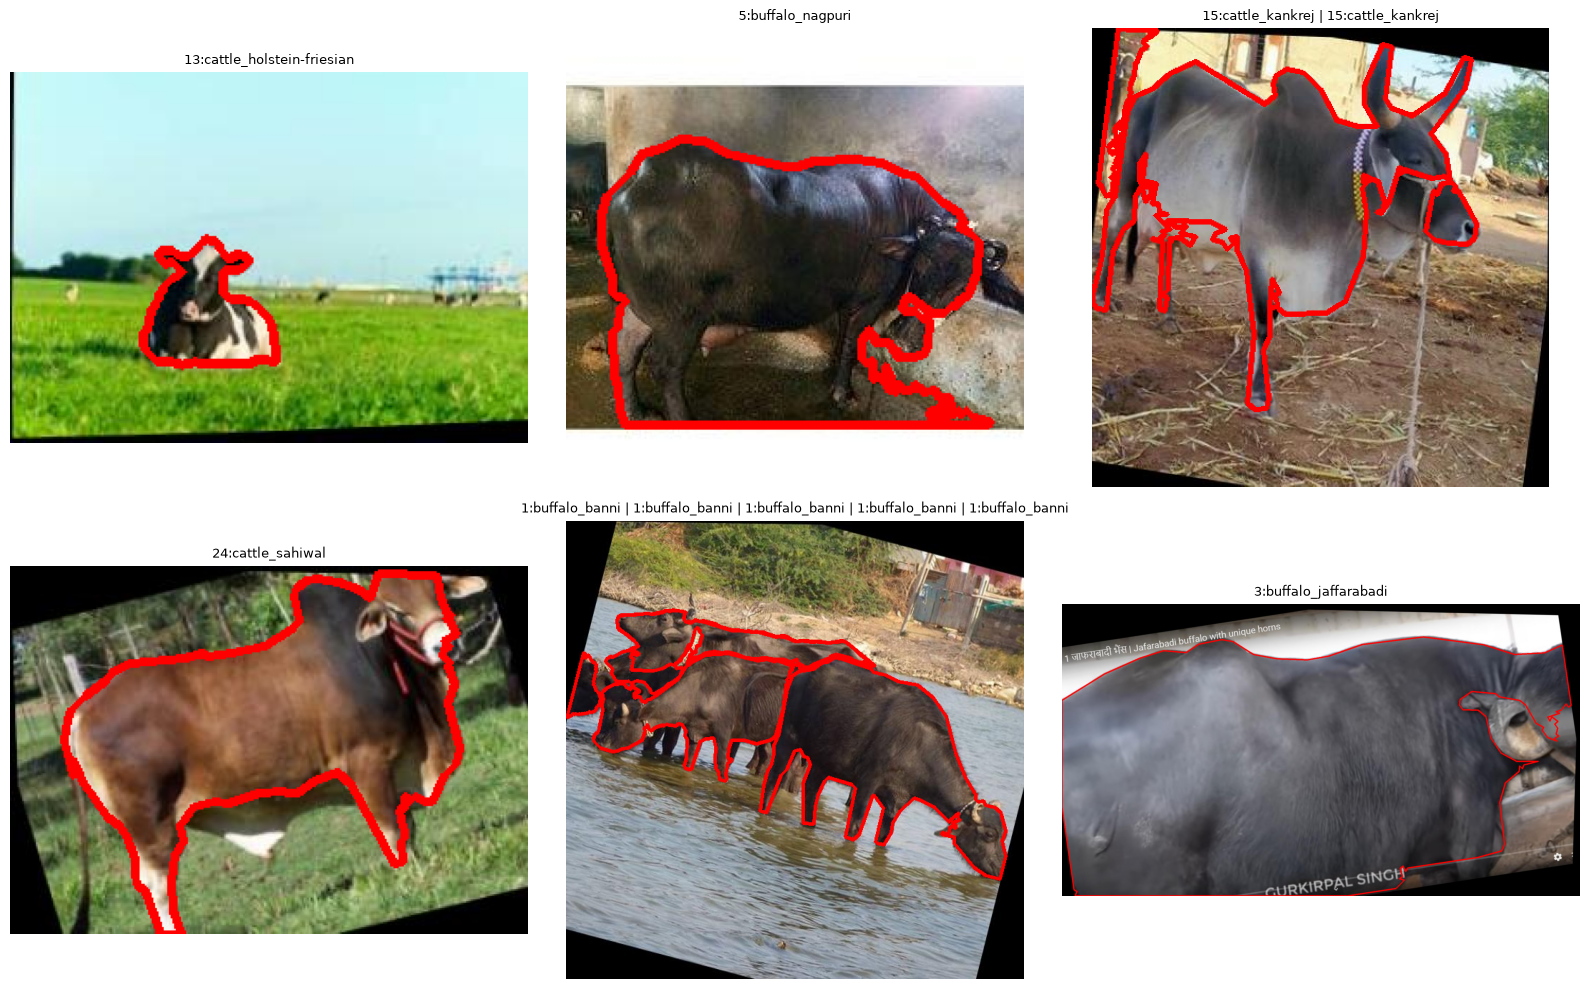

In [14]:
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
import yaml

# -------------------------------------------------------------------
# 1. LOAD data.yaml to get the authoritative class id -> name mapping
# -------------------------------------------------------------------
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

id_to_name = data_yaml["names"]
print("Loaded class names:", len(id_to_name))

# -------------------------------------------------------------------
# 2. PICK random samples across different classes for a spread check
# -------------------------------------------------------------------
random.seed(7)
train_labels_dir = FINAL_DIR / "train" / "labels"
train_images_dir = FINAL_DIR / "train" / "images"

all_label_files = list(train_labels_dir.glob("*.txt"))
sample_labels = random.sample(all_label_files, 6)

# -------------------------------------------------------------------
# 3. DRAW polygons + print resolved class name as the title
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, label_path in zip(axes, sample_labels):
    stem = label_path.stem
    img_path = None
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        candidate = train_images_dir / f"{stem}{ext}"
        if candidate.exists():
            img_path = candidate
            break

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    class_names_in_image = []
    for line in lines:
        parts = list(map(float, line.split()))
        cls_id = int(parts[0])
        coords = parts[1:]
        points = np.array(coords).reshape(-1, 2)
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(np.int32)

        cv2.polylines(img, [points], isClosed=True, color=(255, 0, 0), thickness=3)
        class_names_in_image.append(f"{cls_id}:{id_to_name[cls_id]}")

    ax.imshow(img)
    ax.set_title(" | ".join(class_names_in_image), fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FINAL_DIR / "final_dataset_sanity_check.png", dpi=120)
plt.show()

In [15]:
# from ultralytics import YOLO

# # -------------------------------------------------------------------
# # 1. LOAD pretrained YOLOv8 segmentation model (nano)
# # -------------------------------------------------------------------
# seg_model = YOLO("yolov8n-seg.pt")

# # -------------------------------------------------------------------
# # 2. TRAIN — baseline run, clearly labeled for later comparison
# # -------------------------------------------------------------------
# baseline_results = seg_model.train(
#     data=str(data_yaml_path),
#     epochs=50,
#     imgsz=640,
#     batch=8,
#     patience=15,
#     device=0,
#     workers=4,
#     project="breed_segmentation",
#     name="yolov8n_seg_baseline",     # <-- clearly marked as "before optimization"
#     verbose=True
# )

In [16]:
import shutil

BASELINE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\runs\segment\breed_segmentation\yolov8n_seg_baseline")
EVAL_ARCHIVE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\evaluation_before_optimization")
EVAL_ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

# Copy every auto-generated plot/metric file into our clearly-labeled archive
files_to_copy = [
    "results.png", "results.csv",
    "confusion_matrix.png", "confusion_matrix_normalized.png",
    "BoxP_curve.png", "BoxR_curve.png", "BoxPR_curve.png", "BoxF1_curve.png",
    "MaskP_curve.png", "MaskR_curve.png", "MaskPR_curve.png", "MaskF1_curve.png",
]

copied = 0
for fname in files_to_copy:
    src = BASELINE_DIR / fname
    if src.exists():
        shutil.copy2(src, EVAL_ARCHIVE_DIR / fname)
        copied += 1

print(f"Copied {copied}/{len(files_to_copy)} baseline evaluation files to: {EVAL_ARCHIVE_DIR}")

Copied 12/12 baseline evaluation files to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\evaluation_before_optimization


In [17]:
from ultralytics import YOLO

# -------------------------------------------------------------------
# 1. LOAD a fresh pretrained model (starting clean, not continuing baseline)
# -------------------------------------------------------------------
seg_model_opt = YOLO("yolov8n-seg.pt")

# -------------------------------------------------------------------
# 2. TRAIN — optimized run: stronger augmentation + longer patience
# -------------------------------------------------------------------
optimized_results = seg_model_opt.train(
    data=str(data_yaml_path),
    epochs=100,
    imgsz=640,
    batch=8,
    patience=30,          # <-- A: more room to keep improving before stopping
    device=0,
    workers=4,

    # --- B: augmentation settings ---
    degrees=15.0,          # random rotation up to ±15° (matches our Roboflow choice, realistic camera tilt)
    translate=0.1,         # random shift up to 10% of image size (simulates off-center framing)
    scale=0.3,             # random zoom in/out up to 30% (simulates camera distance variation)
    shear=5.0,             # slight shear, consistent with our earlier Roboflow setting
    fliplr=0.5,            # 50% chance horizontal flip — realistic (animal facing either direction)
    flipud=0.0,            # explicitly OFF — an upside-down animal is never realistic
    mosaic=1.0,            # combines 4 training images into one — proven technique for small datasets, adds variety
    mixup=0.1,             # occasionally blends two images — mild regularization, helps generalization
    copy_paste=0.1,        # pastes segmented instances from one image onto another — directly increases effective instance count per class, which is exactly our data-scarcity problem

    project="breed_segmentation",
    name="yolov8n_seg_optimized",     # <-- clearly marked as "after optimization"
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.130 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.106  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_seg_dataset\final\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_wid

In [18]:
OPTIMIZED_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\runs\segment\breed_segmentation\yolov8n_seg_optimized-2")
EVAL_ARCHIVE_OPT_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\evaluation_after_optimization")
EVAL_ARCHIVE_OPT_DIR.mkdir(parents=True, exist_ok=True)

copied = 0
for fname in files_to_copy:  # reusing the same list from Step 6
    src = OPTIMIZED_DIR / fname
    if src.exists():
        shutil.copy2(src, EVAL_ARCHIVE_OPT_DIR / fname)
        copied += 1

print(f"Copied {copied}/{len(files_to_copy)} optimized evaluation files to: {EVAL_ARCHIVE_OPT_DIR}")

Copied 12/12 optimized evaluation files to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\Yolo_seg\evaluation_after_optimization
